# Regression Baseline: Increasing Model Complexity

This notebook trains regression models on the stratified county split data (CASTHMA and COPD targets), **increasing in complexity** following the data science lecture sequence:

1. **Simple linear regression** (one feature) — *04_linear_regression/01_simple_linear_regression*
2. **Multiple linear regression** (numeric features only) — *04_linear_regression/02_multiple_linear_regression*
3. **Categorical variables and preprocessing** (pipeline: impute, scale, one-hot) — *04_linear_regression/03_categorical_variables_and_interaction*
4. **Regularization (Ridge, Lasso, ElasticNet)** — *03_complexity_control/02_regularization*
5. **Hyperparameter tuning** (GridSearchCV with grouped CV) — *03_complexity_control/04_hyperparameter_tuning*
6. **XGBoost** — *11_ensemble_ii/04_xgboost*

Enhancements: **both targets** (CASTHMA & COPD), **CV metrics** and **bootstrap CIs** for test metrics, **diagnostic plots** for all linear/ensemble models, **unified top-features** table, **SHAP** for XGBoost, and an **interpretation** section. Model 2/3 use **Ridge** (not OLS) for stability.

## Setup and paths

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold, cross_val_predict, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_style("whitegrid")

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "modeling" else Path.cwd()
DATA_DIR = REPO_ROOT / "data"
RESULTS_DIR = REPO_ROOT / "modeling" / "results"

TARGET_PATHS = {
    "CASTHMA": {"train": DATA_DIR / "train_CASTHMA.csv", "test": DATA_DIR / "test_CASTHMA.csv"},
    "COPD": {"train": DATA_DIR / "train_COPD.csv", "test": DATA_DIR / "test_COPD.csv"},
}

DEFAULT_DROP_COLUMNS = {
    "index", "FIPS", "NAME", "state_fips", "CASTHMA", "COPD",
    "CSMOKING", "OBESITY", "DIABETES", "cat3_CASTHMA", "cat3_COPD",
}

ALPHA_GRID = np.logspace(-3, 3, 13)
RANDOM_STATE = 42
CV_FOLDS = 5
N_BOOT = 100   # bootstrap samples for test-metric CIs

# Run for both targets
TARGETS = ["CASTHMA", "COPD"]

## Data splits (train / test)

Following *02_model_evaluation/01_data_splits*: we use a **training set** to fit and compare models, and a **testing set** only for final evaluation. The data are already split by county (stratified) so we load pre-made train/test files.

In [3]:
def choose_feature_columns(train_df: pd.DataFrame, target: str) -> list:
    # Always drop both CASTHMA and COPD so we never use one outcome to predict the other or the target as a feature.
    drop = set(DEFAULT_DROP_COLUMNS)
    return [c for c in train_df.columns if c not in drop]

data = {}
for TARGET in TARGETS:
    train_df = pd.read_csv(TARGET_PATHS[TARGET]["train"])
    test_df = pd.read_csv(TARGET_PATHS[TARGET]["test"])
    feature_columns = choose_feature_columns(train_df, TARGET)
    data[TARGET] = {
        "train_df": train_df,
        "test_df": test_df,
        "X_train": train_df[feature_columns].copy(),
        "X_test": test_df[feature_columns].copy(),
        "y_train": train_df[TARGET].copy(),
        "y_test": test_df[TARGET].copy(),
        "groups": train_df["FIPS"].copy(),
        "feature_columns": feature_columns,
    }
    print(f"{TARGET}: train {len(train_df)}, test {len(test_df)}, features {len(feature_columns)}")

# For backward compatibility in later cells that index by first target
TARGET = TARGETS[0]
train_df = data[TARGET]["train_df"]
test_df = data[TARGET]["test_df"]
X_train = data[TARGET]["X_train"]
X_test = data[TARGET]["X_test"]
y_train = data[TARGET]["y_train"]
y_test = data[TARGET]["y_test"]
groups = data[TARGET]["groups"]
feature_columns = data[TARGET]["feature_columns"]
data[TARGET]["X_train"].head()

CASTHMA: train 4871, test 1217, features 480
COPD: train 4871, test 1217, features 480


,YEAR,pesticide_total_kg,pesticide_anilide_kg,pesticide_carbamate_kg,pesticide_chlorophenoxy_kg,pesticide_organochlorine_kg,pesticide_organophosphate_kg,pesticide_other_kg,pesticide_pyrethroid_kg,pesticide_triazine_kg,...,ipm_breadth_value,chemical_reliance_value,ipm_doc_coverage_share,mean_text_quality,mean_geo_confidence,weighted_doc_age,county_crop_concentration,specialty_crop_share,total_ag_value,ipm_primary_match_tier
0,2018,34773.85,3690.60,397.30,6995.35,0.0,2033.75,20854.80,119.65,682.4,...,NaN,NaN,0.0,NaN,NaN,NaN,0.135210,0.0,NaN,NaN
1,2019,21120.00,2582.55,9.70,5230.55,0.0,763.95,11639.25,16.80,877.2,...,NaN,NaN,0.0,NaN,NaN,NaN,0.135210,0.0,NaN,NaN
2,2018,277331.10,61192.90,1327.20,10561.50,0.0,4287.00,185663.25,1982.75,12316.5,...,NaN,NaN,0.0,NaN,NaN,NaN,0.218801,0.0,NaN,NaN
3,2019,125643.65,30532.30,24.45,4197.00,0.0,7219.45,75275.55,127.30,8267.6,...,NaN,NaN,0.0,NaN,NaN,NaN,0.218801,0.0,NaN,NaN
4,2018,63256.35,3484.60,306.80,11760.30,0.0,1455.95,42686.50,626.70,2935.5,...,NaN,NaN,0.0,NaN,NaN,NaN,0.211528,0.0,NaN,NaN


---
## Model 1: Simple linear regression

As in *04_linear_regression/01_simple_linear_regression*: we predict $y$ with a single feature $x$:
$$y = \beta_0 + \beta_1 x + \epsilon$$
We fit by minimizing **MSE** (equivalently RMSE). We pick one numeric feature (e.g. total pesticide) for illustration.

In [4]:
# Pick one numeric feature (e.g. total pesticide)
numeric_cols = X_train.select_dtypes(include=["number", "bool"]).columns.tolist()
single_feature = "pesticide_total_kg" if "pesticide_total_kg" in numeric_cols else numeric_cols[0]

x_simple = X_train[[single_feature]].copy()
x_simple_test = X_test[[single_feature]].copy()

# Impute for safety (median)
imp = SimpleImputer(strategy="median")
x_simple_imp = imp.fit_transform(x_simple)
x_simple_test_imp = imp.transform(x_simple_test)

model_simple = LinearRegression()
model_simple.fit(x_simple_imp, y_train)

pred_simple = model_simple.predict(x_simple_test_imp)
rmse_simple = np.sqrt(mean_squared_error(y_test, pred_simple))
r2_simple = r2_score(y_test, pred_simple)

print(f"Simple LR (feature: {single_feature})")
print(f"  Intercept: {model_simple.intercept_:.4f}, Coef: {model_simple.coef_[0]:.6f}")
print(f"  Test RMSE: {rmse_simple:.4f}, R²: {r2_simple:.4f}")

Simple LR (feature: pesticide_total_kg)
  Intercept: 9.8207, Coef: -0.000000
  Test RMSE: 1.0009, R²: -0.0158


---
## Model 2: Multiple linear regression (Ridge)

As in *04_linear_regression/02_multiple_linear_regression* with *03_complexity_control/02_regularization*: we use many numeric features but fit **Ridge** (not OLS) so the solution is stable with multicollinearity.

In [5]:
numeric_features = X_train.select_dtypes(include=["number", "bool"]).columns.tolist()
X_train_num = X_train[numeric_features].copy()
X_test_num = X_test[numeric_features].copy()

pipe_num = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0)),
])
pipe_num.fit(X_train_num, y_train)
pred_multi = pipe_num.predict(X_test_num)
rmse_multi = np.sqrt(mean_squared_error(y_test, pred_multi))
r2_multi = r2_score(y_test, pred_multi)

print("Multiple LR (Ridge, numeric features only)")
print(f"  Test RMSE: {rmse_multi:.4f}, R²: {r2_multi:.4f}")
print(f"  Number of features: {len(numeric_features)}")

Multiple LR (Ridge, numeric features only)
  Test RMSE: 5.3024, R²: -27.5065
  Number of features: 480


/opt/homebrew/Caskroom/miniforge/base/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['ipm_breadth_acre' 'chemical_reliance_acre' 'ipm_breadth_acre_rescaled'
 'chemical_reliance_acre_rescaled' 'ipm_breadth_value'
 'chemical_reliance_value' 'mean_text_quality' 'mean_geo_confidence'
 'weighted_doc_age' 'total_ag_value' 'ipm_primary_match_tier']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['ipm_breadth_acre' 'chemical_reliance_acre' 'ipm_breadth_acre_rescaled'
 'chemical_reliance_acre_rescaled' 'ipm_breadth_value'
 'chemical_reliance_value' 'mean_text_quality' 'mean_geo_confidence'
 'weighted_doc_age' 'total_ag_value' 'ipm_primary_match_tier']. At least one non-

---
## Model 3: Categorical variables and full preprocessing (Ridge)

As in *04_linear_regression/03_categorical_variables_and_interaction*: we include **categorical** predictors via **one-hot encoding**. We fit **Ridge** on the full design matrix so the solution stays stable.

In [6]:
def build_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    numeric_features = X.select_dtypes(include=["number", "bool"]).columns.tolist()
    categorical_features = [c for c in X.columns if c not in numeric_features]
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])
    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_features),
            ("cat", categorical_pipeline, categorical_features),
        ],
        remainder="drop",
    )

preprocessor = build_preprocessor(X_train)
X_train_full = preprocessor.fit_transform(X_train)
X_test_full = preprocessor.transform(X_test)

model_full = Ridge(alpha=1.0)
model_full.fit(X_train_full, y_train)

pred_full = model_full.predict(X_test_full)
rmse_full = np.sqrt(mean_squared_error(y_test, pred_full))
r2_full = r2_score(y_test, pred_full)

n_features_out = X_train_full.shape[1]
print("Multiple LR (Ridge, numeric + categorical, full preprocessing)")
print(f"  Test RMSE: {rmse_full:.4f}, R²: {r2_full:.4f}")
print(f"  Design matrix columns after preprocessing: {n_features_out}")

/opt/homebrew/Caskroom/miniforge/base/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['ipm_breadth_acre' 'chemical_reliance_acre' 'ipm_breadth_acre_rescaled'
 'chemical_reliance_acre_rescaled' 'ipm_breadth_value'
 'chemical_reliance_value' 'mean_text_quality' 'mean_geo_confidence'
 'weighted_doc_age' 'total_ag_value' 'ipm_primary_match_tier']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['ipm_breadth_acre' 'chemical_reliance_acre' 'ipm_breadth_acre_rescaled'
 'chemical_reliance_acre_rescaled' 'ipm_breadth_value'
 'chemical_reliance_value' 'mean_text_quality' 'mean_geo_confidence'
 'weighted_doc_age' 'total_ag_value' 'ipm_primary_match_tier']. At least one non-

Multiple LR (Ridge, numeric + categorical, full preprocessing)
  Test RMSE: 5.3024, R²: -27.5065
  Design matrix columns after preprocessing: 469


---
## Model 4 & 5: Ridge, Lasso, and ElasticNet with hyperparameter tuning

As in *03_complexity_control/02_regularization*: **Ridge** ($\ell_2$), **Lasso** ($\ell_1$, can zero out coefficients), **ElasticNet** (mix of both via `l1_ratio`). We use **GridSearchCV** with grouped, stratified CV.

In [7]:
def make_strata(y: pd.Series, n_bins: int = 5) -> pd.Series:
    n_unique = y.nunique(dropna=True)
    bins = max(2, min(n_bins, n_unique))
    return pd.qcut(y, q=bins, labels=False, duplicates="drop")

strata = make_strata(y_train)
cv_splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
fold_indices = list(cv_splitter.split(X_train, strata, groups))

preprocessor = build_preprocessor(X_train)

ridge_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", Ridge()),
])
lasso_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", Lasso(max_iter=20000, random_state=RANDOM_STATE)),
])
elastic_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", ElasticNet(max_iter=20000, random_state=RANDOM_STATE)),
])

ridge_search = GridSearchCV(
    ridge_pipeline,
    param_grid={"model__alpha": ALPHA_GRID},
    cv=fold_indices,
    scoring="neg_root_mean_squared_error",
    refit=True,
)
lasso_search = GridSearchCV(
    lasso_pipeline,
    param_grid={"model__alpha": ALPHA_GRID},
    cv=fold_indices,
    scoring="neg_root_mean_squared_error",
    refit=True,
)
elastic_search = GridSearchCV(
    elastic_pipeline,
    param_grid={"model__alpha": ALPHA_GRID, "model__l1_ratio": [0.25, 0.5, 0.75]},
    cv=fold_indices,
    scoring="neg_root_mean_squared_error",
    refit=True,
)

ridge_search.fit(X_train, y_train)
lasso_search.fit(X_train, y_train)
elastic_search.fit(X_train, y_train)

pred_ridge = ridge_search.predict(X_test)
pred_lasso = lasso_search.predict(X_test)
pred_elastic = elastic_search.predict(X_test)

print("Ridge (tuned):")
print(f"  Best alpha: {ridge_search.best_params_['model__alpha']}")
print(f"  CV RMSE: {-ridge_search.best_score_:.4f}")
print(f"  Test RMSE: {np.sqrt(mean_squared_error(y_test, pred_ridge)):.4f}, R²: {r2_score(y_test, pred_ridge):.4f}")
print("Lasso (tuned):")
print(f"  Best alpha: {lasso_search.best_params_['model__alpha']}")
print(f"  CV RMSE: {-lasso_search.best_score_:.4f}")
print(f"  Test RMSE: {np.sqrt(mean_squared_error(y_test, pred_lasso)):.4f}, R²: {r2_score(y_test, pred_lasso):.4f}")
print("ElasticNet (tuned):")
print(f"  Best alpha: {elastic_search.best_params_['model__alpha']}, l1_ratio: {elastic_search.best_params_['model__l1_ratio']}")
print(f"  CV RMSE: {-elastic_search.best_score_:.4f}")
print(f"  Test RMSE: {np.sqrt(mean_squared_error(y_test, pred_elastic)):.4f}, R²: {r2_score(y_test, pred_elastic):.4f}")

/opt/homebrew/Caskroom/miniforge/base/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['ipm_breadth_acre' 'chemical_reliance_acre' 'ipm_breadth_acre_rescaled'
 'chemical_reliance_acre_rescaled' 'ipm_breadth_value'
 'chemical_reliance_value' 'mean_text_quality' 'mean_geo_confidence'
 'weighted_doc_age' 'total_ag_value' 'ipm_primary_match_tier']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['ipm_breadth_acre' 'chemical_reliance_acre' 'ipm_breadth_acre_rescaled'
 'chemical_reliance_acre_rescaled' 'ipm_breadth_value'
 'chemical_reliance_value' 'mean_text_quality' 'mean_geo_confidence'
 'weighted_doc_age' 'total_ag_value' 'ipm_primary_match_tier']. At least one non-

Ridge (tuned):
  Best alpha: 1000.0
  CV RMSE: 0.8061
  Test RMSE: 0.7267, R²: 0.4646
Lasso (tuned):
  Best alpha: 0.01
  CV RMSE: 0.6466
  Test RMSE: 0.6332, R²: 0.5935
ElasticNet (tuned):
  Best alpha: 0.01, l1_ratio: 0.75
  CV RMSE: 0.6523
  Test RMSE: 0.6390, R²: 0.5860


/opt/homebrew/Caskroom/miniforge/base/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['ipm_breadth_acre' 'chemical_reliance_acre' 'ipm_breadth_acre_rescaled'
 'chemical_reliance_acre_rescaled' 'ipm_breadth_value'
 'chemical_reliance_value' 'mean_text_quality' 'mean_geo_confidence'
 'weighted_doc_age' 'total_ag_value' 'ipm_primary_match_tier']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['ipm_breadth_acre' 'chemical_reliance_acre' 'ipm_breadth_acre_rescaled'
 'chemical_reliance_acre_rescaled' 'ipm_breadth_value'
 'chemical_reliance_value' 'mean_text_quality' 'mean_geo_confidence'
 'weighted_doc_age' 'total_ag_value' 'ipm_primary_match_tier']. At least one non-

---
## Model 6: XGBoost

As in *11_ensemble_ii/04_xgboost*: **XGBoost** is gradient boosting with a second-order (Newton-style) approximation of the loss; it is often faster and can perform better than first-order boosting. We use the same preprocessor as for Ridge/Lasso, then fit an **XGBRegressor**. We tune a small grid (e.g. `max_depth`, `learning_rate`, `n_estimators`) via GridSearchCV with the same grouped CV, and optionally use early stopping.

In [8]:
# XGBoost pipeline: same preprocessor, then XGBRegressor
preprocessor_xgb = build_preprocessor(X_train)
xgb_pipeline = Pipeline([
    ("preprocess", preprocessor_xgb),
    ("model", XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
])

# Optional: tune a few key hyperparameters (or use defaults)
param_grid_xgb = {
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.05, 0.1],
    "model__n_estimators": [100, 200],
}
xgb_search = GridSearchCV(
    xgb_pipeline,
    param_grid=param_grid_xgb,
    cv=fold_indices,
    scoring="neg_root_mean_squared_error",
    refit=True,
    n_jobs=1,
)
xgb_search.fit(X_train, y_train)

pred_xgb = xgb_search.predict(X_test)
print("XGBoost (tuned):")
print(f"  Best params: {xgb_search.best_params_}")
print(f"  CV RMSE: {-xgb_search.best_score_:.4f}")
print(f"  Test RMSE: {np.sqrt(mean_squared_error(y_test, pred_xgb)):.4f}, R²: {r2_score(y_test, pred_xgb):.4f}")

/opt/homebrew/Caskroom/miniforge/base/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['ipm_breadth_acre' 'chemical_reliance_acre' 'ipm_breadth_acre_rescaled'
 'chemical_reliance_acre_rescaled' 'ipm_breadth_value'
 'chemical_reliance_value' 'mean_text_quality' 'mean_geo_confidence'
 'weighted_doc_age' 'total_ag_value' 'ipm_primary_match_tier']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['ipm_breadth_acre' 'chemical_reliance_acre' 'ipm_breadth_acre_rescaled'
 'chemical_reliance_acre_rescaled' 'ipm_breadth_value'
 'chemical_reliance_value' 'mean_text_quality' 'mean_geo_confidence'
 'weighted_doc_age' 'total_ag_value' 'ipm_primary_match_tier']. At least one non-

XGBoost (tuned):
  Best params: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200}
  CV RMSE: 0.4220
  Test RMSE: 0.3956, R²: 0.8413


/opt/homebrew/Caskroom/miniforge/base/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['ipm_breadth_acre' 'chemical_reliance_acre' 'ipm_breadth_acre_rescaled'
 'chemical_reliance_acre_rescaled' 'ipm_breadth_value'
 'chemical_reliance_value' 'mean_text_quality' 'mean_geo_confidence'
 'weighted_doc_age' 'total_ag_value' 'ipm_primary_match_tier']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


---
## Regression metrics and summary

As in *02_model_evaluation/02_regression_metrics*: we report **RMSE** (same scale as $y$), **MAE**, and **R²** for each model on the test set.

In [ ]:
def metrics_row(name, y_true, y_pred, cv_rmse=None):
    row = {
        "model": name,
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "r2": float(r2_score(y_true, y_pred)),
    }
    if cv_rmse is not None:
        row["cv_rmse"] = cv_rmse
    return row

def bootstrap_ci(y_true, y_pred, n_boot=N_BOOT, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    rmse_boot = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        rmse_boot.append(np.sqrt(mean_squared_error(y_true.iloc[idx], y_pred[idx])))
    return np.percentile(rmse_boot, [2.5, 97.5])

pred_by_name = {
    "Simple LR (1 feat)": pred_simple,
    "Multiple LR (Ridge, numeric)": pred_multi,
    "Multiple LR (Ridge, full preprocess)": pred_full,
    "Ridge (tuned)": pred_ridge,
    "Lasso (tuned)": pred_lasso,
    "ElasticNet (tuned)": pred_elastic,
    "XGBoost (tuned)": pred_xgb,
}
rows = [
    metrics_row("Simple LR (1 feat)", y_test, pred_simple),
    metrics_row("Multiple LR (Ridge, numeric)", y_test, pred_multi),
    metrics_row("Multiple LR (Ridge, full preprocess)", y_test, pred_full),
    metrics_row("Ridge (tuned)", y_test, pred_ridge, cv_rmse=-ridge_search.best_score_),
    metrics_row("Lasso (tuned)", y_test, pred_lasso, cv_rmse=-lasso_search.best_score_),
    metrics_row("ElasticNet (tuned)", y_test, pred_elastic, cv_rmse=-elastic_search.best_score_),
    metrics_row("XGBoost (tuned)", y_test, pred_xgb, cv_rmse=-xgb_search.best_score_),
]
for r in rows:
    ci = bootstrap_ci(y_test, pred_by_name[r["model"]])
    r["rmse_ci_low"], r["rmse_ci_high"] = ci[0], ci[1]
summary = pd.DataFrame(rows).sort_values("rmse")
summary

,model,rmse,mae,r2,rmse_ci_low,rmse_ci_high,cv_rmse
6,XGBoost (tuned),0.395622,0.306409,0.841304,0.378290,0.414564,0.422010
4,Lasso (tuned),0.633181,0.500910,0.593499,0.604894,0.652456,0.646589
5,ElasticNet (tuned),0.639012,0.501099,0.585978,0.610379,0.664392,0.652289
3,Ridge (tuned),0.726651,0.535581,0.464626,0.670647,0.774728,0.806107
0,Simple LR (1 feat),1.000911,0.788001,-0.015773,0.951741,1.041892,NaN
1,"Multiple LR (Ridge, numeric)",5.302360,0.897466,-27.506502,1.967985,7.606543,NaN
2,"Multiple LR (Ridge, full preprocess)",5.302360,0.897466,-27.506502,1.967985,7.606543,NaN


---
## Regression diagnostic plots

As in *02_model_evaluation/03_regression_plots*: **actual vs predicted** and **residuals** to assess fit and homoscedasticity.

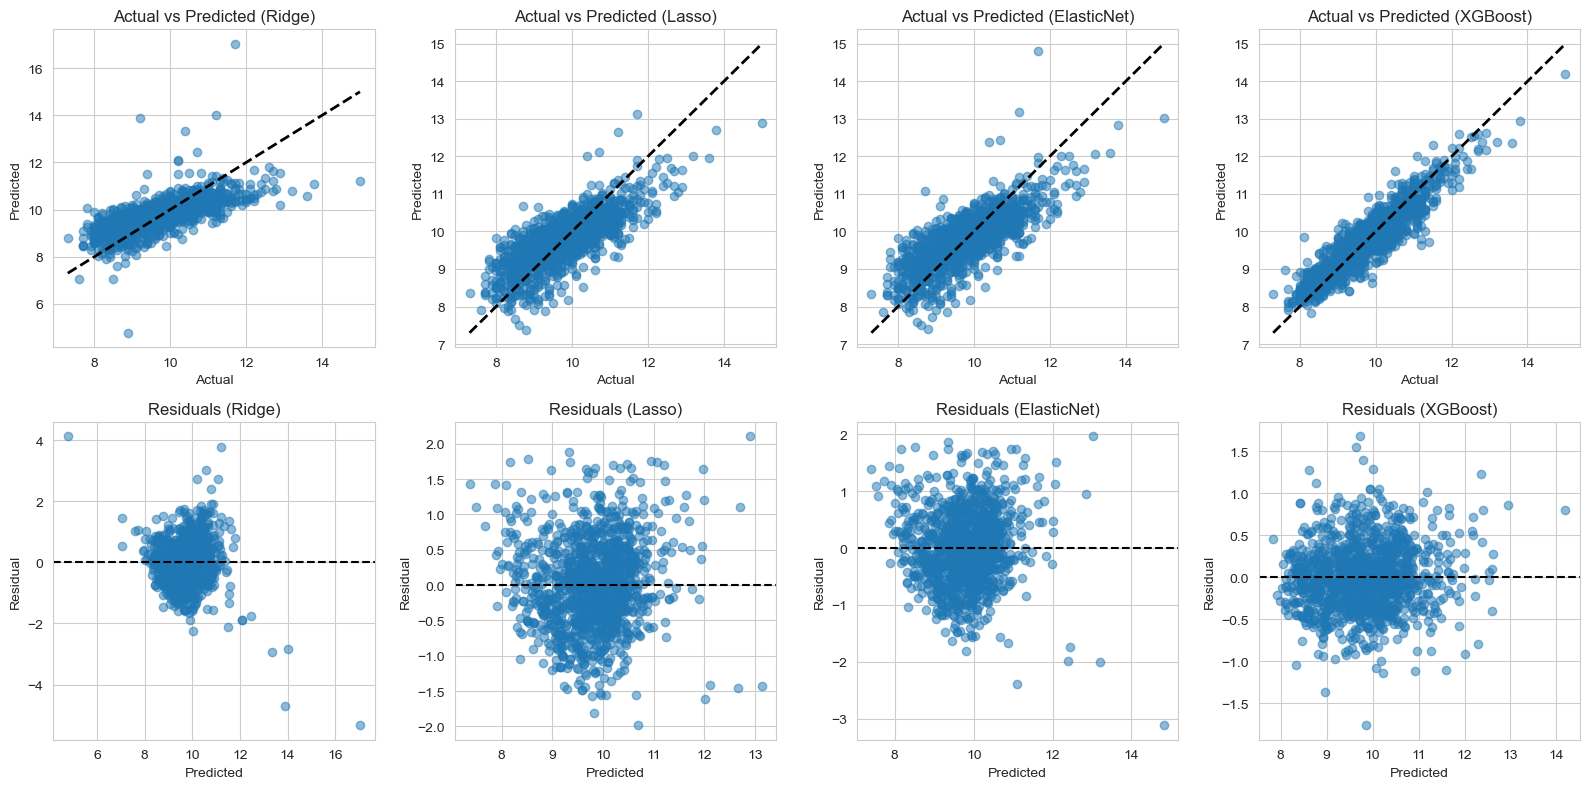

In [ ]:
# Diagnostic plots for Ridge, Lasso, ElasticNet, XGBoost
plot_models = [("Ridge", pred_ridge), ("Lasso", pred_lasso), ("ElasticNet", pred_elastic), ("XGBoost", pred_xgb)]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for j, (name, y_pred_plot) in enumerate(plot_models):
    resid = y_test - y_pred_plot
    axes[0, j].scatter(y_test, y_pred_plot, alpha=0.5)
    axes[0, j].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--", lw=2)
    axes[0, j].set_xlabel("Actual")
    axes[0, j].set_ylabel("Predicted")
    axes[0, j].set_title(f"Actual vs Predicted ({name})")
    axes[1, j].scatter(y_pred_plot, resid, alpha=0.5)
    axes[1, j].axhline(0, color="k", ls="--")
    axes[1, j].set_xlabel("Predicted")
    axes[1, j].set_ylabel("Residual")
    axes[1, j].set_title(f"Residuals ({name})")
plt.tight_layout()
plt.show()

---
## Top coefficients / feature importances (Ridge / Lasso / XGBoost)

Inspect which features (after preprocessing) have the largest absolute coefficients (Ridge, Lasso) or the largest feature importance (XGBoost). Lasso often zeros out some; Ridge shrinks but rarely to zero.

In [ ]:
def top_coefficients(search, top_n=15):
    names = search.best_estimator_.named_steps["preprocess"].get_feature_names_out()
    coef = search.best_estimator_.named_steps["model"].coef_
    df = pd.DataFrame({"feature": names, "coefficient": coef, "abs_coef": np.abs(coef)})
    return df.sort_values("abs_coef", ascending=False).head(top_n)

print("Ridge — top 15 by |coefficient|")
display(top_coefficients(ridge_search))
print("Lasso — top 15 by |coefficient|")
display(top_coefficients(lasso_search))
print("ElasticNet — top 15 by |coefficient|")
display(top_coefficients(elastic_search))
print("XGBoost — top 15 by feature importance")
fnames = xgb_search.best_estimator_.named_steps["preprocess"].get_feature_names_out()
imp = xgb_search.best_estimator_.named_steps["model"].feature_importances_
display(pd.DataFrame({"feature": fnames, "importance": imp}).sort_values("importance", ascending=False).head(15))

Ridge — top 15 by |coefficient|


,feature,coefficient,abs_coef
448,num__median_income,-0.379650,0.379650
452,num__pct_hispanic,-0.344910,0.344910
447,num__median_age,-0.097124,0.097124
0,num__YEAR,-0.092112,0.092112
20,num__pesticide_acetochlor_kg,-0.083220,0.083220
290,num__pesticide_metribuzin_kg,0.078643,0.078643
449,num__pct_white,-0.077050,0.077050
394,num__pesticide_sulfentrazone_kg,-0.071315,0.071315
145,num__pesticide_dimethenamid_kg,-0.058267,0.058267
465,num__cropland_diversity,0.049479,0.049479


Lasso — top 15 by |coefficient|


,feature,coefficient,abs_coef
452,num__pct_hispanic,-0.669238,0.669238
448,num__median_income,-0.496390,0.496390
449,num__pct_white,-0.415981,0.415981
450,num__pct_black,-0.258336,0.258336
20,num__pesticide_acetochlor_kg,-0.124138,0.124138
0,num__YEAR,-0.114968,0.114968
394,num__pesticide_sulfentrazone_kg,-0.109946,0.109946
447,num__median_age,-0.105864,0.105864
290,num__pesticide_metribuzin_kg,0.086854,0.086854
465,num__cropland_diversity,0.079461,0.079461


ElasticNet — top 15 by |coefficient|


,feature,coefficient,abs_coef
452,num__pct_hispanic,-0.693782,0.693782
448,num__median_income,-0.498353,0.498353
449,num__pct_white,-0.447927,0.447927
450,num__pct_black,-0.284549,0.284549
20,num__pesticide_acetochlor_kg,-0.120435,0.120435
0,num__YEAR,-0.119685,0.119685
394,num__pesticide_sulfentrazone_kg,-0.107820,0.107820
447,num__median_age,-0.106493,0.106493
290,num__pesticide_metribuzin_kg,0.093862,0.093862
465,num__cropland_diversity,0.079325,0.079325


XGBoost — top 15 by feature importance


,feature,importance
448,num__median_income,0.052481
256,num__pesticide_kasugamycin_kg,0.046565
294,num__pesticide_myclobutanil_kg,0.044658
41,num__pesticide_bacillus_mycoides_kg,0.031733
340,num__pesticide_prohexadione_kg,0.026830
60,num__pesticide_bromacil_kg,0.025365
452,num__pct_hispanic,0.022033
20,num__pesticide_acetochlor_kg,0.020173
65,num__pesticide_butralin_kg,0.019613
154,num__pesticide_dinotefuran_kg,0.019381


---
## Unified top features (Ridge / Lasso / ElasticNet / XGBoost)

Top 10 features side by side for easy comparison across models.

In [ ]:
top_n = 50
ridge_top = top_coefficients(ridge_search, top_n=top_n)[["feature", "abs_coef"]].rename(columns={"abs_coef": "Ridge"})
lasso_top = top_coefficients(lasso_search, top_n=top_n)[["feature", "abs_coef"]].rename(columns={"abs_coef": "Lasso"})
elastic_top = top_coefficients(elastic_search, top_n=top_n)[["feature", "abs_coef"]].rename(columns={"abs_coef": "ElasticNet"})
xgb_imp = pd.DataFrame({"feature": xgb_search.best_estimator_.named_steps["preprocess"].get_feature_names_out(), "XGBoost": xgb_search.best_estimator_.named_steps["model"].feature_importances_}).sort_values("XGBoost", ascending=False).head(top_n)
# Align by feature (inner join on feature name)
unified = ridge_top.merge(lasso_top, on="feature", how="outer").merge(elastic_top, on="feature", how="outer").merge(xgb_imp[["feature", "XGBoost"]], on="feature", how="outer").fillna(0)
display(unified.head(top_n))

,feature,Ridge,Lasso,ElasticNet,XGBoost
0,num__YEAR,0.092112,0.114968,0.119685,0.000000
1,num__cropland_diversity,0.049479,0.079461,0.079325,0.000000
2,num__median_age,0.097124,0.105864,0.106493,0.004459
3,num__median_income,0.379650,0.496390,0.498353,0.052481
4,num__nchs_urban_rural,0.000000,0.049997,0.053767,0.000000
5,num__pct_asian,0.044228,0.043038,0.049544,0.000000
6,num__pct_black,0.000000,0.258336,0.284549,0.005395
7,num__pct_hispanic,0.344910,0.669238,0.693782,0.022033
8,num__pct_white,0.077050,0.415981,0.447927,0.009155
9,num__pesticide_2_4_db_kg,0.000000,0.000000,0.000000,0.005671


---
## SHAP (XGBoost)

SHAP values explain how each feature contributes to predictions. Install with `pip install shap` if needed.

/opt/homebrew/Caskroom/miniforge/base/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['ipm_breadth_acre' 'chemical_reliance_acre' 'ipm_breadth_acre_rescaled'
 'chemical_reliance_acre_rescaled' 'ipm_breadth_value'
 'chemical_reliance_value' 'mean_text_quality' 'mean_geo_confidence'
 'weighted_doc_age' 'total_ag_value' 'ipm_primary_match_tier']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


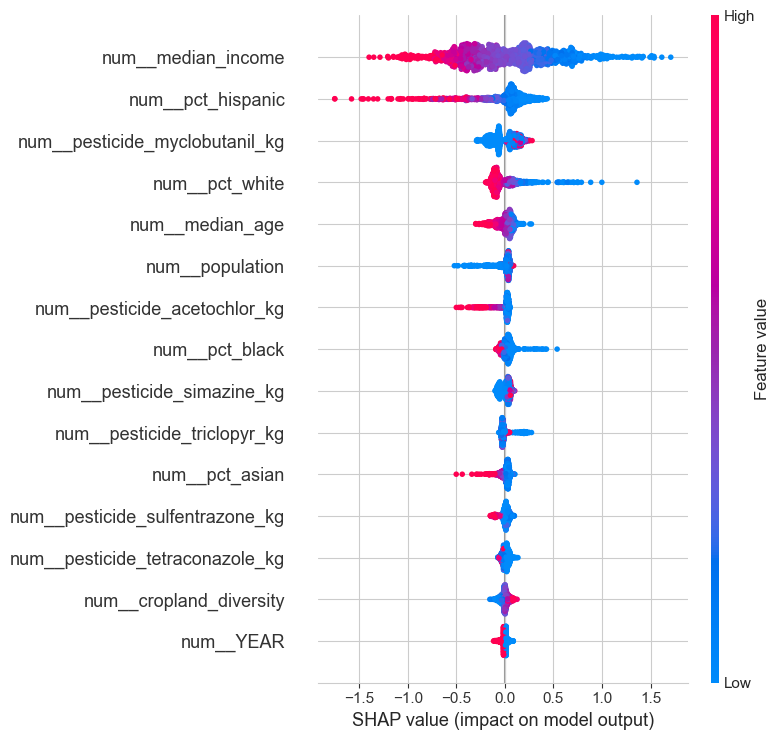

In [ ]:
try:
    import shap
    X_test_preprocessed = xgb_search.best_estimator_.named_steps["preprocess"].transform(X_test)
    xgb_model = xgb_search.best_estimator_.named_steps["model"]
    explainer = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(X_test_preprocessed)
    feature_names = xgb_search.best_estimator_.named_steps["preprocess"].get_feature_names_out()
    shap.summary_plot(shap_values, X_test_preprocessed, feature_names=feature_names, max_display=15, show=False)
    plt.tight_layout()
    plt.show()
except ImportError:
    print("Install shap: pip install shap")

---
## Interpretation

- **Best model**: Check the summary table (sorted by RMSE); typically XGBoost or ElasticNet/Lasso.
- **CV vs test**: `cv_rmse` (from grouped stratified CV) should be in the same ballpark as test RMSE; large gap suggests overfitting or distribution shift.
- **Uncertainty**: `rmse_ci_low` / `rmse_ci_high` are 95% bootstrap CIs for test RMSE; use them to compare models.
- **Features**: Ridge/Lasso/ElasticNet coefficients and XGBoost importance (and SHAP) show which predictors matter; compare across models for robustness.

---
## Full pipeline for both targets

Re-run the full training and evaluation for **each** target so we get metrics and saved outputs for both CASTHMA and COPD. Results are written to `modeling/results/<TARGET>/`.

In [ ]:
def run_pipeline(target):
    d = data[target]
    X_tr, X_te = d["X_train"], d["X_test"]
    y_tr, y_te = d["y_train"], d["y_test"]
    grp = d["groups"]
    strata = make_strata(y_tr)
    folds = list(StratifiedGroupKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE).split(X_tr, strata, grp))
    preproc = build_preprocessor(X_tr)
    # Simple LR
    nc = X_tr.select_dtypes(include=["number", "bool"]).columns.tolist()
    single = "pesticide_total_kg" if "pesticide_total_kg" in nc else nc[0]
    imp = SimpleImputer(strategy="median")
    x1 = imp.fit_transform(X_tr[[single]])
    x1_te = imp.transform(X_te[[single]])
    m_simple = LinearRegression().fit(x1, y_tr)
    p_simple = m_simple.predict(x1_te)
    # Multi Ridge (numeric)
    pipe_num = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()), ("model", Ridge(alpha=1.0))])
    pipe_num.fit(X_tr[nc], y_tr)
    p_multi = pipe_num.predict(X_te[nc])
    # Full Ridge
    preproc.fit(X_tr)
    X_tr_f = preproc.transform(X_tr)
    X_te_f = preproc.transform(X_te)
    m_full = Ridge(alpha=1.0).fit(X_tr_f, y_tr)
    p_full = m_full.predict(X_te_f)
    # Ridge, Lasso, ElasticNet, XGBoost
    r_pipe = Pipeline([("preprocess", preproc), ("model", Ridge())])
    l_pipe = Pipeline([("preprocess", preproc), ("model", Lasso(max_iter=20000, random_state=RANDOM_STATE))])
    e_pipe = Pipeline([("preprocess", preproc), ("model", ElasticNet(max_iter=20000, random_state=RANDOM_STATE))])
    xgb_pipe = Pipeline([("preprocess", preproc), ("model", XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1))])
    r_search = GridSearchCV(r_pipe, param_grid={"model__alpha": ALPHA_GRID}, cv=folds, scoring="neg_root_mean_squared_error", refit=True)
    l_search = GridSearchCV(l_pipe, param_grid={"model__alpha": ALPHA_GRID}, cv=folds, scoring="neg_root_mean_squared_error", refit=True)
    e_search = GridSearchCV(e_pipe, param_grid={"model__alpha": ALPHA_GRID, "model__l1_ratio": [0.25, 0.5, 0.75]}, cv=folds, scoring="neg_root_mean_squared_error", refit=True)
    xgb_search_t = GridSearchCV(xgb_pipe, param_grid={"model__max_depth": [3, 5, 7], "model__learning_rate": [0.05, 0.1], "model__n_estimators": [100, 200]}, cv=folds, scoring="neg_root_mean_squared_error", refit=True, n_jobs=1)
    r_search.fit(X_tr, y_tr)
    l_search.fit(X_tr, y_tr)
    e_search.fit(X_tr, y_tr)
    xgb_search_t.fit(X_tr, y_tr)
    out = {
        "y_test": y_te, "test_df": d["test_df"],
        "pred_simple": p_simple, "pred_multi": p_multi, "pred_full": p_full,
        "pred_ridge": r_search.predict(X_te), "pred_lasso": l_search.predict(X_te),
        "pred_elastic": e_search.predict(X_te), "pred_xgb": xgb_search_t.predict(X_te),
        "ridge_search": r_search, "lasso_search": l_search, "elastic_search": e_search, "xgb_search": xgb_search_t,
    }
    return out

all_results = {}
for t in TARGETS:
    all_results[t] = run_pipeline(t)
    print(f"Done {t}")

# Combined summary with target column
combined_rows = []
for t in TARGETS:
    r = all_results[t]
    y_te = r["y_test"]
    for name, pred in [("Simple LR (1 feat)", r["pred_simple"]), ("Multiple LR (Ridge, numeric)", r["pred_multi"]), ("Multiple LR (Ridge, full)", r["pred_full"]), ("Ridge (tuned)", r["pred_ridge"]), ("Lasso (tuned)", r["pred_lasso"]), ("ElasticNet (tuned)", r["pred_elastic"]), ("XGBoost (tuned)", r["pred_xgb"])]:
        row = {"target": t, "model": name, "rmse": np.sqrt(mean_squared_error(y_te, pred)), "mae": mean_absolute_error(y_te, pred), "r2": r2_score(y_te, pred)}
        ci = bootstrap_ci(y_te, pred)
        row["rmse_ci_low"], row["rmse_ci_high"] = ci[0], ci[1]
        combined_rows.append(row)
combined_summary = pd.DataFrame(combined_rows)
display(combined_summary.sort_values(["target", "rmse"]))

# Save both targets
for t in TARGETS:
    r = all_results[t]
    td = RESULTS_DIR / t
    td.mkdir(parents=True, exist_ok=True)
    sub = combined_summary[combined_summary["target"] == t]
    sub.to_csv(td / "model_summary.csv", index=False)
    for name, pred, search in [("ridge", r["pred_ridge"], r["ridge_search"]), ("lasso", r["pred_lasso"], r["lasso_search"]), ("elasticnet", r["pred_elastic"], r["elastic_search"]), ("xgboost", r["pred_xgb"], r["xgb_search"])]:
        pd.DataFrame({"FIPS": r["test_df"]["FIPS"], "YEAR": r["test_df"]["YEAR"], "actual": r["y_test"], "prediction": pred}).to_csv(td / f"{name}_predictions.csv", index=False)
        if name == "xgboost":
            fn = search.best_estimator_.named_steps["preprocess"].get_feature_names_out()
            im = search.best_estimator_.named_steps["model"].feature_importances_
            pd.DataFrame({"feature": fn, "importance": im}).sort_values("importance", ascending=False).head(25).to_csv(td / "xgboost_top_importances.csv", index=False)
        else:
            top_coefficients(search).to_csv(td / f"{name}_top_coefficients.csv", index=False)
    print(f"Saved {td}")

/opt/homebrew/Caskroom/miniforge/base/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['ipm_breadth_acre' 'chemical_reliance_acre' 'ipm_breadth_acre_rescaled'
 'chemical_reliance_acre_rescaled' 'ipm_breadth_value'
 'chemical_reliance_value' 'mean_text_quality' 'mean_geo_confidence'
 'weighted_doc_age' 'total_ag_value' 'ipm_primary_match_tier']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['ipm_breadth_acre' 'chemical_reliance_acre' 'ipm_breadth_acre_rescaled'
 'chemical_reliance_acre_rescaled' 'ipm_breadth_value'
 'chemical_reliance_value' 'mean_text_quality' 'mean_geo_confidence'
 'weighted_doc_age' 'total_ag_value' 'ipm_primary_match_tier']. At least one non-

Done CASTHMA


/opt/homebrew/Caskroom/miniforge/base/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['ipm_breadth_acre' 'chemical_reliance_acre' 'ipm_breadth_acre_rescaled'
 'chemical_reliance_acre_rescaled' 'ipm_breadth_value'
 'chemical_reliance_value' 'mean_text_quality' 'mean_geo_confidence'
 'weighted_doc_age' 'total_ag_value' 'ipm_primary_match_tier']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['ipm_breadth_acre' 'chemical_reliance_acre' 'ipm_breadth_acre_rescaled'
 'chemical_reliance_acre_rescaled' 'ipm_breadth_value'
 'chemical_reliance_value' 'mean_text_quality' 'mean_geo_confidence'
 'weighted_doc_age' 'total_ag_value' 'ipm_primary_match_tier']. At least one non-

Done COPD


,target,model,rmse,mae,r2,rmse_ci_low,rmse_ci_high
6,CASTHMA,XGBoost (tuned),0.395622,0.306409,0.841304,0.378290,0.414564
4,CASTHMA,Lasso (tuned),0.633181,0.500910,0.593499,0.604894,0.652456
5,CASTHMA,ElasticNet (tuned),0.639012,0.501099,0.585978,0.610379,0.664392
3,CASTHMA,Ridge (tuned),0.726651,0.535581,0.464626,0.670647,0.774728
0,CASTHMA,Simple LR (1 feat),1.000911,0.788001,-0.015773,0.951741,1.041892
1,CASTHMA,"Multiple LR (Ridge, numeric)",5.302360,0.897466,-27.506502,1.967985,7.606543
2,CASTHMA,"Multiple LR (Ridge, full)",5.302360,0.897466,-27.506502,1.967985,7.606543
13,COPD,XGBoost (tuned),0.923424,0.700933,0.839795,0.874027,0.963417
11,COPD,Lasso (tuned),1.382419,1.050222,0.640952,1.289515,1.466907
12,COPD,ElasticNet (tuned),1.460419,1.057750,0.599292,1.325423,1.608234


Saved /Users/allisonlonderee/Desktop/repos/spring-2026-pesticide-exposure/modeling/results/CASTHMA
Saved /Users/allisonlonderee/Desktop/repos/spring-2026-pesticide-exposure/modeling/results/COPD


---
## (Optional) Save results

Mirror the original script: write metrics, predictions, and top coefficients to `modeling/results/<TARGET>/`.

In [ ]:
for TARGET in TARGETS:
    target_dir = RESULTS_DIR / TARGET
    target_dir.mkdir(parents=True, exist_ok=True)
    # Use current run (first target); for second target we'd need to re-run or use full pipeline below
    if TARGET != TARGETS[0]:
        continue
    _test_df = data[TARGET]["test_df"]
    _y_test = data[TARGET]["y_test"]
    summary.to_csv(target_dir / "model_summary.csv", index=False)
    for name, pred, search in [
        ("ridge", pred_ridge, ridge_search),
        ("lasso", pred_lasso, lasso_search),
        ("elasticnet", pred_elastic, elastic_search),
        ("xgboost", pred_xgb, xgb_search),
    ]:
        pd.DataFrame({"FIPS": _test_df["FIPS"], "YEAR": _test_df["YEAR"], "actual": _y_test, "prediction": pred}).to_csv(
            target_dir / f"{name}_predictions.csv", index=False
        )
        if name == "xgboost":
            fnames = search.best_estimator_.named_steps["preprocess"].get_feature_names_out()
            imp = search.best_estimator_.named_steps["model"].feature_importances_
            pd.DataFrame({"feature": fnames, "importance": imp}).sort_values("importance", ascending=False).head(25).to_csv(
                target_dir / "xgboost_top_importances.csv", index=False
            )
        else:
            top_coefficients(search).to_csv(target_dir / f"{name}_top_coefficients.csv", index=False)
    print(f"Results saved to {target_dir}")

Results saved to /Users/allisonlonderee/Desktop/repos/spring-2026-pesticide-exposure/modeling/results/CASTHMA
